Found 19 frames
Frame size  : 1022 x 195 px
Scale       : 3.900 px/mm
Bead px     : 11.7 px diameter
Effective FPS: 6.0
Frame 0000 | H=24.1mm (0.48) | Vel=N/Amm/s | Angle=9.6° | VoidFrac=0.407 [DBG]
Frame 0001 | H=24.0mm (0.48) | Vel=N/Amm/s | Angle=10.0° | VoidFrac=0.408
Frame 0002 | H=24.0mm (0.48) | Vel=N/Amm/s | Angle=10.5° | VoidFrac=0.407
Frame 0003 | H=24.0mm (0.48) | Vel=N/Amm/s | Angle=9.5° | VoidFrac=0.407
Frame 0004 | H=32.7mm (0.65) | Vel=N/Amm/s | Angle=20.5° | VoidFrac=0.407
Frame 0005 | H=33.9mm (0.68) | Vel=N/Amm/s | Angle=34.9° | VoidFrac=0.407
Frame 0006 | H=34.5mm (0.69) | Vel=-21.5mm/s | Angle=62.5° | VoidFrac=0.407
Frame 0007 | H=34.6mm (0.69) | Vel=-21.5mm/s | Angle=39.6° | VoidFrac=0.407
Frame 0008 | H=33.4mm (0.67) | Vel=-21.5mm/s | Angle=53.4° | VoidFrac=0.407
Frame 0009 | H=33.8mm (0.68) | Vel=-21.5mm/s | Angle=72.0° | VoidFrac=0.407
Frame 0010 | H=32.7mm (0.65) | Vel=-21.5mm/s | Angle=54.8° | VoidFrac=0.407 [DBG]
Frame 0011 | H=24.0mm (0.48) | Vel=7.7mm/s | A

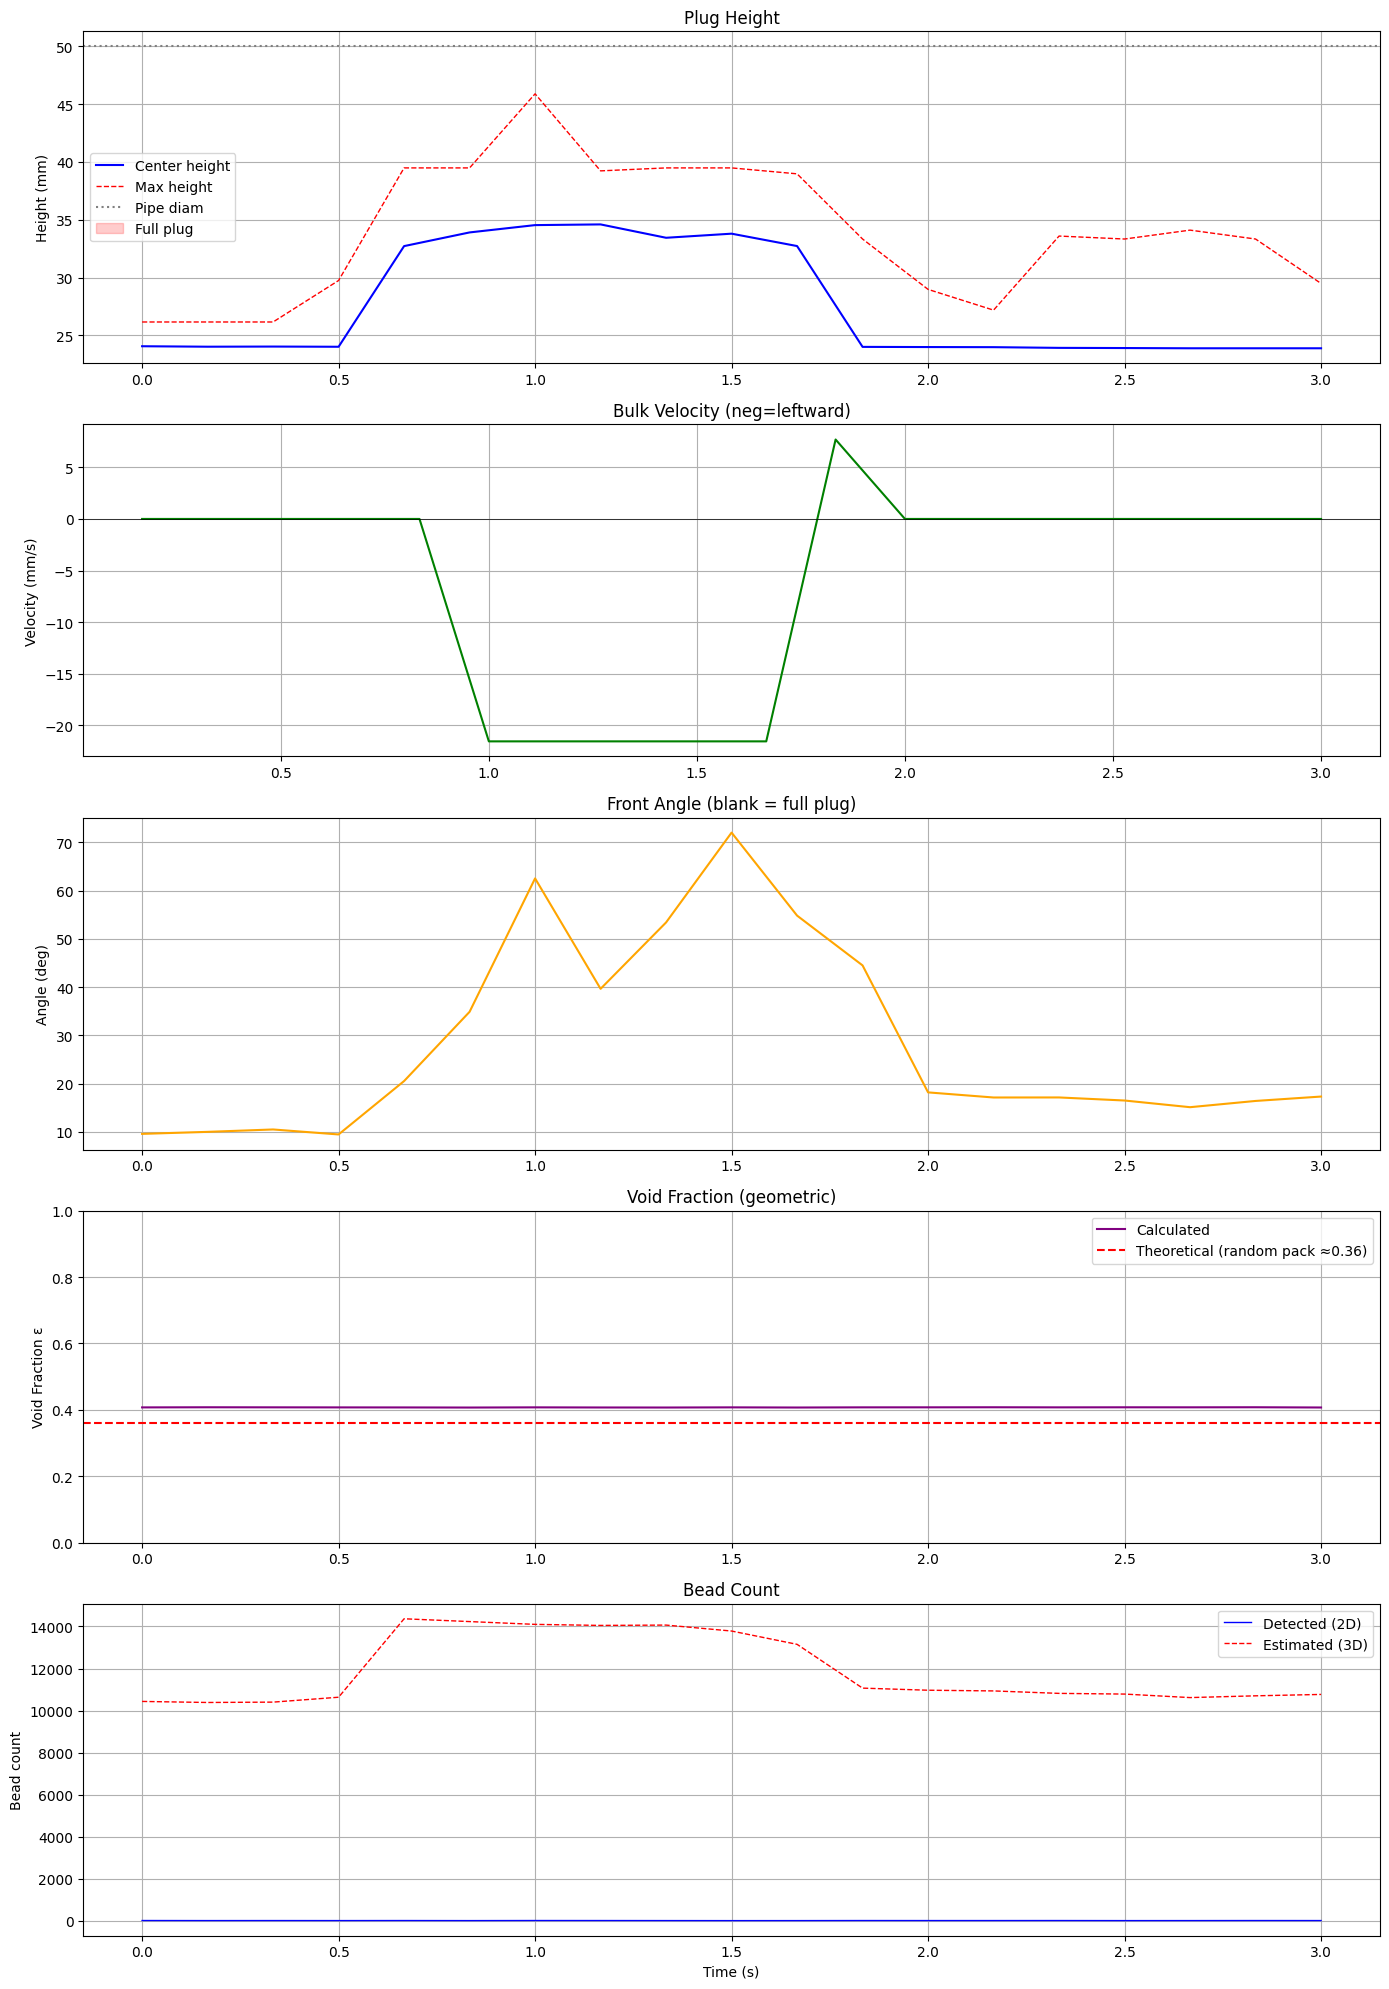

   frame_index    time_s  height_center_mm  height_max_mm  height_ratio  \
0            0  0.000000         24.054801      26.153846      0.481096   
1            1  0.166667         24.014580      26.153846      0.480292   
2            2  0.333333         24.027149      26.153846      0.480543   
3            3  0.500000         24.009553      29.743590      0.480191   
4            4  0.666667         32.719960      39.487179      0.654399   
5            5  0.833333         33.903972      39.487179      0.678079   
6            6  1.000000         34.537456      45.897436      0.690749   
7            7  1.166667         34.597788      39.230769      0.691956   
8            8  1.333333         33.441428      39.487179      0.668829   
9            9  1.500000         33.795877      39.487179      0.675918   

   plug_is_full  front_angle_deg  bulk_velocity_mm_s  void_fraction  \
0         False         9.589528                 NaN       0.407284   
1         False        10.007060

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import correlate, savgol_filter
from scipy.ndimage import label as scipy_label
import os
import glob

# ============================================================
# CONFIGURATION
# ============================================================
PIPE_DIAMETER_MM  = 50.0   # pipe inner diameter
BEAD_DIAMETER_MM  = 3.0    # sphere/bead diameter in mm
EFFECTIVE_FPS     = 6.0    # after frame skip (30fps / 5skip)

# Plug is FULL (angle not meaningful) when height > this ratio
FULL_PLUG_RATIO   = 0.92   # 92% of pipe height = "full"

# ============================================================
# HELPERS
# ============================================================

def to_gray(frame):
    if len(frame.shape) == 3:
        return cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return frame.copy()


def save_debug_image(img, folder, filename, title=None):
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, filename)
    disp = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) \
           if len(img.shape) == 2 else img.copy()
    if title:
        # black bar background for readability
        cv2.rectangle(disp, (0,0), (len(title)*11+10, 34),
                      (0,0,0), -1)
        cv2.putText(disp, title, (5, 24),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                    (0,255,255), 2, cv2.LINE_AA)
    cv2.imwrite(path, disp)


def save_fig(fig, folder, filename):
    os.makedirs(folder, exist_ok=True)
    fig.savefig(os.path.join(folder, filename),
                dpi=120, bbox_inches='tight')
    plt.close(fig)


def make_strip(imgs_titles, out_h=250):
    """Horizontal comparison strip."""
    panels = []
    for img, title in imgs_titles:
        p = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) \
            if len(img.shape)==2 else img.copy()
        h, w = p.shape[:2]
        nw = max(1, int(w * out_h / h))
        p  = cv2.resize(p, (nw, out_h))
        bar = np.zeros((35, nw, 3), np.uint8)
        cv2.putText(bar, title, (4,24),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55,
                    (0,255,255), 1, cv2.LINE_AA)
        panels.append(np.vstack([bar, p]))
    mh = max(p.shape[0] for p in panels)
    out = []
    for p in panels:
        d = mh - p.shape[0]
        if d > 0:
            p = np.vstack([p, np.zeros((d,p.shape[1],3),np.uint8)])
        out.append(p)
    return np.hstack(out)


# ============================================================
# CALIBRATION (image already = pipe interior)
# ============================================================

def calibrate(frame_shape, pipe_diam_mm, bead_diam_mm):
    H, W      = frame_shape[:2]
    px_per_mm = H / pipe_diam_mm
    bead_px   = bead_diam_mm * px_per_mm
    return H, W, px_per_mm, bead_px


# ============================================================
# STEP 2 — IMPROVED PLUG SEGMENTATION
#
# Problem: Otsu on blurred image fails at sparse bead edges.
# Fix:
#   (a) Adaptive threshold (works locally, handles uneven density)
#   (b) Column-wise fill from bottom (plug is CONTIGUOUS from bottom)
#   (c) Smooth the top boundary with Savitzky-Golay filter
# ============================================================

def segment_plug(frame, px_per_mm,
                 debug_folder=None, frame_idx=0,
                 save_debug=False):
    gray = to_gray(frame)
    H, W = gray.shape

    # ── A: Mild blur — preserves bead texture ────────────────
    # Small kernel: merge noise but keep bead edges
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)

    # ── B: Adaptive threshold ─────────────────────────────────
    # Works locally — handles bright beads next to dark background
    # Block size should be ~2x bead diameter in pixels
    bead_px    = int(px_per_mm * 3.0)   # assume ~3mm beads
    block_size = max(11, bead_px * 2 + 1)
    if block_size % 2 == 0:
        block_size += 1

    adapt = cv2.adaptiveThreshold(
        blurred, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=block_size,
        C=-5           # negative C = bias toward bright pixels
    )

    # ── C: Also do Otsu for comparison / combination ──────────
    _, otsu = cv2.threshold(
        blurred, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # ── D: Combine adaptive + Otsu (OR → more complete) ──────
    combined = cv2.bitwise_or(adapt, otsu)

    # ── E: Morphology — fill bead gaps ────────────────────────
    # Close: fill dark gaps between beads
    k1 = np.ones((9,9),  np.uint8)
    k2 = np.ones((5,5),  np.uint8)
    closed = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, k1)
    opened = cv2.morphologyEx(closed,   cv2.MORPH_OPEN,  k2)

    # ── F: Column-wise fill from BOTTOM ───────────────────────
    # The plug is ALWAYS connected from the pipe bottom.
    # For each column: scan from bottom up, keep white pixels
    # until we hit the first continuous gap > threshold rows
    gap_threshold = int(px_per_mm * 2.0)  # 2mm gap = plug end

    col_mask = np.zeros((H, W), dtype=np.uint8)
    for x in range(W):
        col   = opened[:, x]
        # Find topmost contiguous white region from bottom
        in_plug   = False
        gap_count = 0
        top_of_plug = H  # assume no plug

        for y in range(H-1, -1, -1):
            if col[y] > 0:
                in_plug   = True
                gap_count = 0
                top_of_plug = y
            else:
                if in_plug:
                    gap_count += 1
                    if gap_count > gap_threshold:
                        # Gap too large: plug ends here
                        break

        # Fill column from bottom to top_of_plug
        if top_of_plug < H:
            col_mask[top_of_plug:H, x] = 255

    # ── G: Smooth top boundary horizontally ──────────────────
    # Get top boundary pixel per column
    top_boundary_y = np.full(W, H, dtype=float)
    for x in range(W):
        ys = np.where(col_mask[:, x] > 0)[0]
        if len(ys) > 0:
            top_boundary_y[x] = ys.min()

    # Savitzky-Golay smoothing of top boundary
    win = min(51, W // 10)
    if win % 2 == 0:
        win += 1
    try:
        smooth_top = savgol_filter(top_boundary_y, win, 3)
    except Exception:
        smooth_top = top_boundary_y

    smooth_top = np.clip(smooth_top, 0, H-1).astype(int)

    # Rebuild mask from smoothed boundary
    smooth_mask = np.zeros((H, W), dtype=np.uint8)
    for x in range(W):
        if smooth_top[x] < H:
            smooth_mask[smooth_top[x]:H, x] = 255

    # ── Debug images ─────────────────────────────────────────
    if debug_folder and save_debug:
        sf = os.path.join(debug_folder,
                          f'step2_seg/frame_{frame_idx:04d}')

        save_debug_image(gray,       sf, 'A_original.png',
                         'A: Original')
        save_debug_image(blurred,    sf, 'B_blur7x7.png',
                         'B: Blur 7x7 (mild)')
        save_debug_image(adapt,      sf, 'C_adaptive.png',
                         'C: Adaptive Threshold')
        save_debug_image(otsu,       sf, 'D_otsu.png',
                         'D: Otsu Threshold')
        save_debug_image(combined,   sf, 'E_combined.png',
                         'E: Adaptive OR Otsu')
        save_debug_image(closed,     sf, 'F_closed.png',
                         'F: After CLOSE 9x9')
        save_debug_image(col_mask,   sf, 'G_column_fill.png',
                         'G: Column-fill from bottom')
        save_debug_image(smooth_mask,sf, 'H_smoothed.png',
                         'H: Smooth top boundary')

        # Overlay on original
        vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
        vis[smooth_mask > 0] = (0, 180, 0)
        # Draw smooth boundary
        for x in range(W-1):
            cv2.line(vis,
                     (x,   int(smooth_top[x])),
                     (x+1, int(smooth_top[x+1])),
                     (0,0,255), 2)
        save_debug_image(vis, sf, 'I_final_overlay.png',
                         'I: Final (green=plug, red=boundary)')

        strip = make_strip([
            (gray,        'A:Orig'),
            (adapt,       'C:Adapt'),
            (combined,    'E:Combined'),
            (col_mask,    'G:ColFill'),
            (smooth_mask, 'H:Smooth'),
        ])
        cv2.imwrite(os.path.join(sf, 'COMPARISON.png'), strip)

    return smooth_mask, smooth_top


# ============================================================
# STEP 3 — HEIGHT PROFILE (using smooth top boundary)
# ============================================================

def compute_height_profile(smooth_top, H, px_per_mm,
                           debug_folder=None, frame_idx=0,
                           save_debug=False):
    W          = len(smooth_top)
    bottom_y   = H
    heights_px = np.maximum(0, bottom_y - smooth_top)
    heights_mm = heights_px / px_per_mm

    if debug_folder and save_debug:
        sf = os.path.join(debug_folder,
                          f'step3_height/frame_{frame_idx:04d}')
        os.makedirs(sf, exist_ok=True)
        fig, ax = plt.subplots(figsize=(12, 4))
        xs = np.arange(W)
        ax.fill_between(xs, heights_mm, color='skyblue', alpha=0.5)
        ax.plot(xs, heights_mm, 'b-', linewidth=1.5,
                label='Plug height')
        ch = height_at_center(heights_mm)
        ax.axvline(W//2, color='magenta', linestyle='--',
                   label='Center x')
        ax.axhline(ch, color='red', linestyle=':',
                   label=f'H_center={ch:.1f}mm')
        ax.set_xlabel('x (pixels)'); ax.set_ylabel('Height (mm)')
        ax.set_title(f'Frame {frame_idx}: Height Profile')
        ax.legend(); ax.grid(True)
        save_fig(fig, sf, 'height_profile.png')

    return heights_mm


def height_at_center(heights_mm):
    W   = len(heights_mm)
    c   = W // 2
    w10 = max(1, W // 20)
    return float(heights_mm[c-w10:c+w10].mean())


def height_at_x_fraction(heights_mm, frac=0.5):
    return float(heights_mm[int(len(heights_mm)*frac)])


# ============================================================
# STEP 4 — PLUG FRONT ANGLE
#
# Only calculated when plug is PARTIALLY filled.
# When plug height ~ pipe diameter → skip (full plug).
# Leading edge = LEFT side of image (plug flows R→L).
# Use smooth top boundary (no jumps).
# ============================================================

def compute_front_angle(heights_mm, smooth_top, H, px_per_mm,
                        pipe_diam_mm, mask,
                        debug_folder=None, frame_idx=0,
                        save_debug=False):
    """
    Returns (angle_deg, edge_x) or None if plug is full.
    """
    W = len(heights_mm)
    h_center  = height_at_center(heights_mm)
    h_ratio   = h_center / pipe_diam_mm

    # ── Skip if plug is full ─────────────────────────────────
    if h_ratio >= FULL_PLUG_RATIO:
        return None   # no angle when full

    # ── Find left-side rising edge ────────────────────────────
    # Gradient of height profile (smooth, so no spikes)
    grad = np.gradient(heights_mm)

    # Leading edge in LEFT half: steepest rise
    left_half = W // 2
    left_grad = grad[:left_half].copy()

    if left_grad.max() < 0.05:
        return None   # no significant rise = no clear front

    edge_x = int(np.argmax(left_grad))

    # ── Fit line to smooth boundary near edge ─────────────────
    region_half = max(20, int(px_per_mm * 5))   # ~5mm region
    x0 = max(0, edge_x - region_half)
    x1 = min(W, edge_x + region_half)

    xs = np.arange(x0, x1, dtype=np.float32)
    ys = smooth_top[x0:x1].astype(np.float32)

    if len(xs) < 5:
        return None

    # Linear regression
    coeffs = np.polyfit(xs, ys, 1)   # slope, intercept
    slope  = coeffs[0]

    # Angle from horizontal:
    # slope in pixels/pixel (dy/dx in image coords)
    # positive slope = going DOWN in image = rising plug height
    angle_deg = float(np.degrees(np.arctan(-slope)))
    # atan(-slope) because image y is flipped vs math y

    # ── Debug ─────────────────────────────────────────────────
    if debug_folder and save_debug:
        sf = os.path.join(debug_folder,
                          f'step4_angle/frame_{frame_idx:04d}')
        os.makedirs(sf, exist_ok=True)

        fig, axes = plt.subplots(2, 1, figsize=(13, 7))

        # Top: height profile + gradient
        ax  = axes[0]
        ax2 = ax.twinx()
        ax.plot(heights_mm, 'b-', lw=1.5, label='Height (mm)')
        ax2.plot(grad, color='orange', lw=1, alpha=0.8,
                 label='Gradient')
        ax.axvline(edge_x, color='red', linestyle='--',
                   label=f'Edge x={edge_x}')
        ax.axvspan(x0, x1, alpha=0.15, color='red',
                   label='Fit region')
        ax.axvline(W//2, color='gray', linestyle=':', lw=0.8)
        ax.set_ylabel('Height (mm)', color='blue')
        ax2.set_ylabel('Gradient', color='orange')
        ax.set_title(f'Frame {frame_idx}: Front Angle Detection '
                     f'(h_ratio={h_ratio:.2f})')
        ax.legend(loc='upper left', fontsize=7)
        ax2.legend(loc='upper right', fontsize=7)
        ax.grid(True)

        # Bottom: mask with fitted line overlay
        vis = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
        # Draw smooth boundary
        for x in range(W-1):
            cv2.line(vis,
                     (x,   int(smooth_top[x])),
                     (x+1, int(smooth_top[x+1])),
                     (0,255,0), 1)
        # Draw fitted line
        y_fit_x0 = int(np.polyval(coeffs, x0))
        y_fit_x1 = int(np.polyval(coeffs, x1))
        cv2.line(vis, (x0, y_fit_x0), (x1, y_fit_x1),
                 (0,0,255), 3)
        # Horizontal reference
        y_ref = (y_fit_x0 + y_fit_x1)//2
        cv2.line(vis, (x0, y_ref), (x1, y_ref),
                 (255,255,0), 1)
        cv2.putText(vis,
                    f'Angle = {angle_deg:.1f} deg',
                    (x0, max(20, y_fit_x0-15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8,
                    (0,255,0), 2)

        axes[1].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB),
                       aspect='auto')
        axes[1].set_title('Plug Surface + Fitted Angle Line')
        axes[1].axis('off')

        plt.tight_layout()
        save_fig(fig, sf, 'front_angle.png')

    return angle_deg, edge_x


# ============================================================
# STEP 5 — PLUG VELOCITY (cross-correlation on RAW frames)
#
# Do NOT blur before velocity — texture of beads is the signal.
# Use a horizontal strip from the MIDDLE height of plug.
# ============================================================

def compute_plug_velocity(frame1, frame2,
                          heights_mm1, heights_mm2,
                          px_per_mm, effective_fps,
                          debug_folder=None, frame_idx=0,
                          save_debug=False):
    g1 = to_gray(frame1)
    g2 = to_gray(frame2)
    H, W = g1.shape

    # Use middle 50% of plug height as tracking strip
    h_avg   = (height_at_center(heights_mm1) +
               height_at_center(heights_mm2)) / 2.0
    h_px    = int(h_avg * px_per_mm)
    strip_h = max(10, h_px // 3)

    y_bot   = H
    y_top   = max(0, y_bot - h_px + h_px//4)
    y_mid   = min(H, y_top + strip_h)

    strip1  = g1[y_top:y_mid, :]
    strip2  = g2[y_top:y_mid, :]

    # Cross-correlate row averages
    p1 = strip1.mean(axis=0).astype(float)
    p2 = strip2.mean(axis=0).astype(float)
    p1 -= p1.mean()
    p2 -= p2.mean()

    corr     = correlate(p2, p1, mode='full')
    shift_px = corr.argmax() - (W - 1)

    shift_mm      = shift_px / px_per_mm
    velocity_mm_s = shift_mm * effective_fps

    if debug_folder and save_debug:
        sf = os.path.join(debug_folder,
                          f'step5_vel/frame_{frame_idx:04d}')
        os.makedirs(sf, exist_ok=True)

        fig, axes = plt.subplots(3, 1, figsize=(11, 9))

        # Show the strip used
        strip_vis1 = g1.copy()
        cv2.rectangle(strip_vis1, (0,y_top), (W,y_mid),
                      255, 2)
        axes[0].imshow(strip_vis1, cmap='gray', aspect='auto')
        axes[0].set_title(
            f'Frame {frame_idx}: Tracking strip '
            f'(rows {y_top}–{y_mid})'
        )
        axes[0].axis('off')

        axes[1].plot(p1+p1.mean(), 'b-', lw=1,
                     label='Frame N')
        axes[1].plot(p2+p2.mean(), 'r-', lw=1,
                     label='Frame N+1')
        axes[1].set_title('Horizontal intensity profiles')
        axes[1].set_ylabel('Mean intensity')
        axes[1].legend(); axes[1].grid(True)

        lags = np.arange(len(corr)) - (W-1)
        axes[2].plot(lags, corr, 'g-', lw=1)
        axes[2].axvline(shift_px, color='red', linestyle='--',
                        label=f'shift={shift_px}px '
                              f'→ {velocity_mm_s:.1f}mm/s')
        axes[2].set_title('Cross-correlation')
        axes[2].set_xlabel('Lag (px)  [- = leftward]')
        axes[2].legend(); axes[2].grid(True)

        plt.tight_layout()
        save_fig(fig, sf, 'velocity.png')

    return float(velocity_mm_s), int(shift_px)


# ============================================================
# STEP 6 — LAYER VELOCITY (optical flow on RAW frames)
#
# No blurring before optical flow.
# Use Farneback on raw grayscale.
# ============================================================

def compute_layer_velocities(frame1, frame2,
                             smooth_top1, smooth_top2,
                             H, px_per_mm, effective_fps,
                             debug_folder=None, frame_idx=0,
                             save_debug=False):
    g1 = to_gray(frame1)
    g2 = to_gray(frame2)
    W  = g1.shape[1]

    flow = cv2.calcOpticalFlowFarneback(
        g1, g2, None,
        pyr_scale=0.5, levels=3, winsize=21,
        iterations=3, poly_n=5, poly_sigma=1.1, flags=0
    )

    vx_per_row = flow[:,:,0].mean(axis=1)
    vx_mm_s    = vx_per_row / px_per_mm * effective_fps

    y_px = np.arange(H)
    y_mm = (H - y_px) / px_per_mm

    if debug_folder and save_debug:
        sf = os.path.join(debug_folder,
                          f'step6_layers/frame_{frame_idx:04d}')
        os.makedirs(sf, exist_ok=True)

        # Color flow visualization
        mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])
        hsv = np.zeros((H,W,3), dtype=np.uint8)
        hsv[...,0] = ang*180/np.pi/2
        hsv[...,1] = 255
        hsv[...,2] = cv2.normalize(mag,None,0,255,
                                    cv2.NORM_MINMAX)
        flow_bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
        save_debug_image(flow_bgr, sf,
                         'A_flow_color.png',
                         'A: Optical flow '
                         '(color=dir, bright=fast)')

        # Vx heatmap
        vx_map  = flow[:,:,0]
        vx_norm = cv2.normalize(np.abs(vx_map),None,0,255,
                                cv2.NORM_MINMAX).astype(np.uint8)
        save_debug_image(
            cv2.applyColorMap(vx_norm, cv2.COLORMAP_JET),
            sf, 'B_vx_heatmap.png',
            'B: |Vx| heatmap'
        )

        # Layer profile plot
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.plot(vx_mm_s, y_mm, 'b-', lw=1.5)
        ax.fill_betweenx(y_mm, 0, vx_mm_s,
                         alpha=0.3, color='blue')
        ax.axvline(0, color='black', lw=0.5)
        ax.set_xlabel('Velocity (mm/s)')
        ax.set_ylabel('Height from pipe bottom (mm)')
        ax.set_title(f'Frame {frame_idx}: Layer Velocity')
        ax.grid(True)
        save_fig(fig, sf, 'C_layer_profile.png')

    return y_mm, vx_mm_s, flow


# ============================================================
# STEP 7 — VOID FRACTION (GEOMETRIC)
#
# NOT from image dark spots.
# ACTUAL void fraction = inter-particle spaces in a sphere pack.
#
# Method:
#   1. Random packing of spheres: ε ≈ 0.36–0.42 (well known)
#   2. Count visible beads (Hough circle detect on UNBLURRED img)
#   3. Estimate total beads in plug volume
#   4. ε = 1 - (N_beads × V_bead) / V_plug
# ============================================================

def compute_void_fraction(frame, smooth_mask, smooth_top,
                          H, W, px_per_mm,
                          bead_diam_mm, pipe_diam_mm,
                          debug_folder=None, frame_idx=0,
                          save_debug=False):
    """
    Returns dict with void fraction and bead count.
    """
    gray = to_gray(frame)

    bead_radius_px = int(bead_diam_mm * px_per_mm / 2)

    # ── Detect individual beads with Hough circles ────────────
    # Use raw frame (NOT blurred much) inside plug mask only
    masked_gray = cv2.bitwise_and(gray, gray, mask=smooth_mask)

    # Mild equalization to enhance bead edges
    eq = cv2.equalizeHist(masked_gray)

    circles = cv2.HoughCircles(
        eq,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=int(bead_radius_px * 1.5),
        param1=50,
        param2=18,
        minRadius=max(3, bead_radius_px - 3),
        maxRadius=bead_radius_px + 4
    )

    n_detected = 0
    circle_list = []
    if circles is not None:
        circles = np.round(circles[0]).astype(int)
        # Keep only circles inside plug mask
        for (cx, cy, r) in circles:
            if (0 <= cy < H and 0 <= cx < W and
                    smooth_mask[cy, cx] > 0):
                n_detected += 1
                circle_list.append((cx, cy, r))

    # ── Plug volume estimate ──────────────────────────────────
    # Plug cross-section (2D area in pixels)
    plug_area_px2 = float(smooth_mask.sum() / 255)
    plug_area_mm2 = plug_area_px2 / (px_per_mm ** 2)

    # Assume pipe depth = pipe diameter (circular cross-section)
    plug_vol_mm3  = plug_area_mm2 * pipe_diam_mm

    # ── Bead volume ───────────────────────────────────────────
    bead_vol_mm3 = (4/3) * np.pi * (bead_diam_mm/2)**3

    # ── Estimate total beads in plug ─────────────────────────
    # View is 2D: visible beads ≈ 1 layer in depth
    # Depth layers ≈ pipe_diameter / bead_diameter
    depth_layers = pipe_diam_mm / bead_diam_mm

    # From visible area
    bead_area_px2 = np.pi * (bead_radius_px**2)
    visible_area  = plug_area_px2

    if n_detected > 10:
        # Use detected count × depth layers
        n_total_est = int(n_detected * depth_layers)
    else:
        # Fallback: area-based estimate
        # Packing fraction in 2D ≈ 0.65 (random)
        n_visible_est = int(visible_area * 0.65 / bead_area_px2)
        n_total_est   = int(n_visible_est * depth_layers)

    # ── Void fraction ─────────────────────────────────────────
    bead_total_vol  = n_total_est * bead_vol_mm3
    if plug_vol_mm3 > 0:
        vf = max(0.0, min(1.0,
                 1.0 - bead_total_vol / plug_vol_mm3))
    else:
        vf = 0.0

    # Random packing theoretical value (for reference)
    vf_theoretical = 0.36   # random loose packing of spheres

    result = {
        'void_fraction':       vf,
        'void_fraction_theor': vf_theoretical,
        'n_beads_detected':    n_detected,
        'n_beads_estimated':   n_total_est,
        'plug_area_mm2':       plug_area_mm2,
        'plug_vol_mm3':        plug_vol_mm3,
    }

    # ── Debug images ─────────────────────────────────────────
    if debug_folder and save_debug:
        sf = os.path.join(debug_folder,
                          f'step7_void/frame_{frame_idx:04d}')
        os.makedirs(sf, exist_ok=True)

        # Show detected circles
        vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
        for (cx, cy, r) in circle_list[:500]:  # cap display
            cv2.circle(vis, (cx,cy), r, (0,255,0), 1)
            cv2.circle(vis, (cx,cy), 2, (0,0,255), -1)
        cv2.putText(vis,
                    f'{n_detected} beads detected',
                    (10,30), cv2.FONT_HERSHEY_SIMPLEX,
                    0.8, (0,255,255), 2)
        save_debug_image(vis, sf,
                         'A_detected_beads.png',
                         f'A: Hough Circles ({n_detected})')

        save_debug_image(eq, sf,
                         'B_equalized.png',
                         'B: Equalized (input to Hough)')

        fig, ax = plt.subplots(figsize=(7, 4))
        labels = ['Detected\nbeads\n(visible)',
                  'Estimated\ntotal beads',
                  'Plug vol\n(mm³)',
                  'Beads vol\n(mm³)']
        vals   = [n_detected, n_total_est,
                  plug_vol_mm3, bead_total_vol]
        colors = ['green','blue','orange','red']
        ax.bar(labels, vals, color=colors, alpha=0.7)
        ax.set_title(
            f'Frame {frame_idx}: Void fraction = {vf:.3f}  '
            f'(theoretical ≈ {vf_theoretical:.2f})'
        )
        ax.set_ylabel('Count / Volume (mm³)')
        ax.grid(True, axis='y')
        save_fig(fig, sf, 'B_void_analysis.png')

    return result


# ============================================================
# STEP 8 — ANNOTATED FRAME
# ============================================================

def visualize_frame(frame, smooth_mask, smooth_top,
                    heights_mm, px_per_mm, H, W,
                    frame_idx, void_result,
                    angle=None, velocity=None,
                    y_mm=None, vx_mm_s=None,
                    save_path=None,
                    debug_folder=None, save_debug=False):
    gray = to_gray(frame)
    vis  = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    # ── Green plug overlay ──────────────────────────────────
    overlay = vis.copy()
    overlay[smooth_mask > 0] = [0, 160, 0]
    vis = cv2.addWeighted(vis, 0.55, overlay, 0.45, 0)

    # ── Smooth top boundary (red line) ──────────────────────
    for x in range(W - 1):
        y1 = int(np.clip(smooth_top[x],   0, H-1))
        y2 = int(np.clip(smooth_top[x+1], 0, H-1))
        cv2.line(vis, (x,y1), (x+1,y2), (0,0,255), 2)

    # ── Center height line (magenta) ─────────────────────────
    cx     = W // 2
    ch     = height_at_center(heights_mm)
    cy_top = int(np.clip(H - ch*px_per_mm, 0, H-1))
    cv2.line(vis, (cx, cy_top), (cx, H), (255,0,255), 2)
    cv2.putText(vis, f"H={ch:.1f}mm",
                (cx+5, max(18, cy_top+20)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65,
                (255,0,255), 2)

    # ── Info panel ───────────────────────────────────────────
    vf  = void_result['void_fraction']
    n_b = void_result['n_beads_detected']
    info = [
        f"Frame {frame_idx:04d}",
        f"H_center = {ch:.1f} mm",
        f"Void frac = {vf:.3f}",
        f"Beads seen = {n_b}",
    ]
    if velocity is not None:
        d = 'L' if velocity < 0 else 'R'
        info.append(f"Vel = {abs(velocity):.1f} mm/s {d}")
    if angle is not None:
        info.append(f"Front angle = {angle:.1f} deg")

    for li, txt in enumerate(info):
        cv2.putText(vis, txt, (10, 28+li*28),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65,
                    (0,255,255), 2, cv2.LINE_AA)

    # ── Flow arrow ───────────────────────────────────────────
    cv2.arrowedLine(vis, (W-80, H-25), (W-180, H-25),
                    (0,255,255), 3, tipLength=0.35)
    cv2.putText(vis, "Flow", (W-170, H-32),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                (0,255,255), 1)

    if save_path:
        cv2.imwrite(save_path, vis)

    # ── Debug composite ───────────────────────────────────────
    if debug_folder and save_debug:
        sf = os.path.join(debug_folder,
                          f'step8_composite/frame_{frame_idx:04d}')
        os.makedirs(sf, exist_ok=True)

        n_cols = 3 if (y_mm is not None) else 2
        fig, axes = plt.subplots(1, n_cols,
                                 figsize=(6*n_cols, 5))
        axes[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f'Frame {frame_idx}')
        axes[0].axis('off')

        xs = np.arange(W)
        axes[1].fill_between(xs, heights_mm,
                             color='skyblue', alpha=0.5)
        axes[1].plot(xs, heights_mm, 'b-', lw=1.5)
        axes[1].axhline(ch, color='red', linestyle=':',
                        label=f'H={ch:.1f}mm')
        axes[1].set_xlabel('x (px)')
        axes[1].set_ylabel('Height (mm)')
        axes[1].set_title('Height Profile')
        axes[1].legend(); axes[1].grid(True)

        if y_mm is not None:
            axes[2].plot(vx_mm_s, y_mm, 'g-', lw=1.5)
            axes[2].fill_betweenx(y_mm, 0, vx_mm_s,
                                  alpha=0.25, color='green')
            axes[2].axvline(0, color='k', lw=0.5)
            axes[2].set_xlabel('Velocity (mm/s)')
            axes[2].set_ylabel('Height from bottom (mm)')
            axes[2].set_title('Layer Velocity')
            axes[2].grid(True)

        plt.tight_layout()
        save_fig(fig, sf, 'composite.png')

    return vis


# ============================================================
# MAIN PIPELINE
# ============================================================

def run_pipeline(frames_folder, output_folder,
                 pipe_diam_mm    = 50.0,
                 bead_diam_mm    = 3.0,
                 effective_fps   = 6.0,
                 debug_every_n   = 10):

    os.makedirs(output_folder, exist_ok=True)
    annotated_dir = os.path.join(output_folder, 'annotated_frames')
    debug_dir     = os.path.join(output_folder, 'debug_stages')
    os.makedirs(annotated_dir, exist_ok=True)
    os.makedirs(debug_dir,     exist_ok=True)

    paths = sorted(
        glob.glob(os.path.join(frames_folder, '*.png')) +
        glob.glob(os.path.join(frames_folder, '*.jpg'))
    )
    print(f"Found {len(paths)} frames")

    first  = cv2.imread(paths[0], cv2.IMREAD_GRAYSCALE)
    FH, FW = first.shape
    FH_out, FW_out, px_per_mm, bead_px = calibrate(
        first.shape, pipe_diam_mm, bead_diam_mm
    )

    print(f"Frame size  : {FW} x {FH} px")
    print(f"Scale       : {px_per_mm:.3f} px/mm")
    print(f"Bead px     : {bead_px:.1f} px diameter")
    print(f"Effective FPS: {effective_fps}")

    results      = []
    prev_frame   = None
    prev_mask    = None
    prev_top     = None
    prev_heights = None
    y_mm_last    = None
    vx_last      = None

    for i, path in enumerate(paths):
        frame = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if frame is None:
            continue
        H, W   = frame.shape
        save_d  = (debug_every_n > 0 and i % debug_every_n == 0)

        # Step 2: Segment
        smooth_mask, smooth_top = segment_plug(
            frame, px_per_mm,
            debug_folder=debug_dir,
            frame_idx=i, save_debug=save_d
        )

        # Step 3: Height
        heights_mm = compute_height_profile(
            smooth_top, H, px_per_mm,
            debug_folder=debug_dir,
            frame_idx=i, save_debug=save_d
        )
        h_center  = height_at_center(heights_mm)
        h_max     = float(heights_mm.max())
        h_ratio   = h_center / pipe_diam_mm

        # Step 4: Front angle (only when partial plug)
        front_angle = None
        angle_result = compute_front_angle(
            heights_mm, smooth_top, H, px_per_mm,
            pipe_diam_mm, smooth_mask,
            debug_folder=debug_dir,
            frame_idx=i, save_debug=save_d
        )
        if angle_result:
            front_angle = angle_result[0]

        # Step 7: Void fraction (geometric)
        void_result = compute_void_fraction(
            frame, smooth_mask, smooth_top,
            H, W, px_per_mm,
            bead_diam_mm, pipe_diam_mm,
            debug_folder=debug_dir,
            frame_idx=i, save_debug=save_d
        )

        # Steps 5 & 6: Velocity (need previous frame)
        bulk_velocity = None
        flow          = None
        if prev_frame is not None:
            bulk_velocity, shift_px = compute_plug_velocity(
                prev_frame, frame,
                prev_heights, heights_mm,
                px_per_mm, effective_fps,
                debug_folder=debug_dir,
                frame_idx=i, save_debug=save_d
            )
            y_mm_last, vx_last, flow = compute_layer_velocities(
                prev_frame, frame,
                prev_top, smooth_top,
                H, px_per_mm, effective_fps,
                debug_folder=debug_dir,
                frame_idx=i, save_debug=save_d
            )

        # Step 8: Annotated frame
        vis = visualize_frame(
            frame, smooth_mask, smooth_top,
            heights_mm, px_per_mm, H, W,
            frame_idx=i,
            void_result=void_result,
            angle=front_angle,
            velocity=bulk_velocity,
            y_mm=y_mm_last,
            vx_mm_s=vx_last,
            save_path=os.path.join(annotated_dir,
                                   f'frame_{i:04d}.png'),
            debug_folder=debug_dir,
            save_debug=save_d
        )

        results.append({
            'frame_index':        i,
            'time_s':             i / effective_fps,
            'height_center_mm':   h_center,
            'height_max_mm':      h_max,
            'height_ratio':       h_ratio,
            'plug_is_full':       h_ratio >= FULL_PLUG_RATIO,
            'front_angle_deg':    front_angle,
            'bulk_velocity_mm_s': bulk_velocity,
            'void_fraction':      void_result['void_fraction'],
            'void_fraction_theor':void_result['void_fraction_theor'],
            'n_beads_detected':   void_result['n_beads_detected'],
            'n_beads_estimated':  void_result['n_beads_estimated'],
            'plug_area_mm2':      void_result['plug_area_mm2'],
        })

        prev_frame   = frame
        prev_mask    = smooth_mask
        prev_top     = smooth_top
        prev_heights = heights_mm

        v_str = f"{bulk_velocity:.1f}" if bulk_velocity else "N/A"
        a_str = f"{front_angle:.1f}°"  if front_angle  else "FULL"
        print(f"Frame {i:04d} | H={h_center:.1f}mm "
              f"({'FULL' if h_ratio>=FULL_PLUG_RATIO else f'{h_ratio:.2f}'})"
              f" | Vel={v_str}mm/s | Angle={a_str} "
              f"| VoidFrac={void_result['void_fraction']:.3f}"
              + (" [DBG]" if save_d else ""))

    df = pd.DataFrame(results)
    df.to_csv(os.path.join(output_folder, 'results.csv'),
              index=False)

    plot_summary(df, output_folder, pipe_diam_mm)
    return df


# ============================================================
# SUMMARY PLOT
# ============================================================

def plot_summary(df, output_folder, pipe_diam_mm):
    fig, axes = plt.subplots(5, 1, figsize=(14, 20))
    t = df['time_s']

    axes[0].plot(t, df['height_center_mm'], 'b-',
                 lw=1.5, label='Center height')
    axes[0].plot(t, df['height_max_mm'], 'r--',
                 lw=1, label='Max height')
    axes[0].axhline(pipe_diam_mm, color='gray',
                    linestyle=':', label='Pipe diam')
    axes[0].fill_between(t,
        df['height_center_mm'],
        where=df['plug_is_full'],
        color='red', alpha=0.2, label='Full plug')
    axes[0].set_ylabel('Height (mm)')
    axes[0].set_title('Plug Height')
    axes[0].legend(); axes[0].grid(True)

    vel = df['bulk_velocity_mm_s'].dropna()
    axes[1].plot(df['time_s'][vel.index], vel,
                 'g-', lw=1.5)
    axes[1].axhline(0, color='k', lw=0.5)
    axes[1].set_ylabel('Velocity (mm/s)')
    axes[1].set_title('Bulk Velocity (neg=leftward)')
    axes[1].grid(True)

    ang = df['front_angle_deg'].dropna()
    axes[2].plot(df['time_s'][ang.index], ang,
                 color='orange', lw=1.5)
    axes[2].set_ylabel('Angle (deg)')
    axes[2].set_title('Front Angle (blank = full plug)')
    axes[2].grid(True)

    axes[3].plot(t, df['void_fraction'], 'purple',
                 lw=1.5, label='Calculated')
    axes[3].axhline(df['void_fraction_theor'].iloc[0],
                    color='red', linestyle='--',
                    label='Theoretical (random pack ≈0.36)')
    axes[3].set_ylabel('Void Fraction ε')
    axes[3].set_title('Void Fraction (geometric)')
    axes[3].set_ylim(0, 1)
    axes[3].legend(); axes[3].grid(True)

    axes[4].plot(t, df['n_beads_detected'], 'b-',
                 lw=1, label='Detected (2D)')
    axes[4].plot(t, df['n_beads_estimated'], 'r--',
                 lw=1, label='Estimated (3D)')
    axes[4].set_xlabel('Time (s)')
    axes[4].set_ylabel('Bead count')
    axes[4].set_title('Bead Count')
    axes[4].legend(); axes[4].grid(True)

    plt.tight_layout()
    out = os.path.join(output_folder, 'summary_plot.png')
    plt.savefig(out, dpi=150)
    plt.show()


# ============================================================
# RUN
# ============================================================
if __name__ == '__main__':
    df = run_pipeline(
        frames_folder  = 'frames/',
        output_folder  = 'output/',
        pipe_diam_mm   = 50.0,    # ← YOUR pipe diameter
        bead_diam_mm   = 3.0,     # ← YOUR bead diameter
        effective_fps  = 6.0,     # ← 30fps / 5skip
        debug_every_n  = 10
    )
    print(df.head(10))